# CNN Demonstration In Python

## Background
Image classification is one of the most common applications of deep learning.
In this exercise, we will use the CIFAR-10 dataset, a benchmark dataset widely used in computer vision research.

## What is the CIFAR-10 Dataset?
- A large collection of 60,000 color images (RGB), each of size 32×32 pixels.
- The dataset is divided into 10 object categories: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.
- Data split:

   • 50,000 images for training
   
   • 10,000 images for testing


This dataset is small enough to train on a personal computer but complex enough to learn the fundamentals of deep learning–based image classification.

## Objectives
By the end of this practical demo, you will be able to:

1. Load and preprocess image data from CIFAR-10.
2. Build a Convolutional Neural Network (CNN) for image classification.
3. Train the CNN to classify images into 10 categories.
4. Evaluate model performance using accuracy on test data.
5. Test the trained model with a custom image.

### 1. Importing Libraries 

In [1]:
# Deep Learning Example: CIFAR-10 Image Classification
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings("ignore")

**Use Of Each Library**

cifar10 → Dataset module containing CIFAR-10 (60,000 images, 32×32 color, 10 classes).

Sequential → A linear stack model where layers are added one after another.

Conv2D → 2D convolutional layer for extracting image features.

MaxPooling2D → Downsampling layer that reduces spatial dimensions (height & width).

Flatten → Converts 2D feature maps into a 1D vector (to feed into fully connected layers).

Dense → Fully connected layer (like in traditional neural nets).

Dropout → Regularization technique to prevent overfitting by randomly "dropping" neurons.

to_categorical → Converts integer labels into one-hot encoded vectors.

### 2. Load CIFAR-10 Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

CIFAR-10 has 60,000 images (32×32 RGB), equally divided into 10 classes.
The 50,000 training images and 10,000 test images are predefined by the creators of the CIFAR-10 dataset
- Training set (x_train, y_train) → 50,000 images
- Test set (x_test, y_test) → 10,000 images
- x_train → Shape (50000, 32, 32, 3) → pixel values of training images
- y_train → Shape (50000, 1) → labels (0–9 for 10 classes)
- x_test → Shape (10000, 32, 32, 3)
- y_test → Shape (10000, 1)

### 3. Preprocessing

In [3]:
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = to_categorical(y_train), to_categorical(y_test)

**Image normalization:** - Dividing by 255.0 scales pixel values from [0–255] → [0–1], which speeds up training and helps convergence.

**One-hot encoding:**
- Before: y_train[0] = [3] (just a class number)
- After: y_train[0] = [0,0,0,1,0,0,0,0,0,0] (one-hot vector of length 10).This is required for categorical_crossentropy loss

### 4. Build CNN model

- CNN (Convolutional Neural Network) is a deep learning model mainly used for image classification and recognition.
- It uses convolutional filters to automatically detect features like edges, shapes, and objects.
- Pooling layers reduce image size while keeping important details, making the model efficient.
- Unlike traditional neural networks, CNNs require fewer parameters and handle images better.
- They provide translation invariance, meaning an object can be recognized anywhere in the image.
- CNNs are widely used in computer vision tasks like face recognition, medical imaging, and self-driving cars.

In [4]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

Layer by layer:

**Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3))**

- 32 filters, each 3×3 in size.

- Extracts features like edges & textures.

- input_shape=(32,32,3) → 32×32 pixels, 3 color channels (RGB).

**MaxPooling2D(2,2)** - Downsamples image by factor of 2 → reduces computation, retains important features.

**Conv2D(64, (3,3), activation='relu')** - Another convolutional layer, but with 64 filters → learns more complex features.

**MaxPooling2D(2,2)** - Again reduces size.

**Flatten()** - Converts 2D feature maps into a flat vector, so it can be fed into dense layers.

**Dense(128, activation='relu')** - Fully connected layer with 128 neurons. Learns high-level patterns.

**Dropout(0.5)** - Randomly drops 50% of neurons during training to prevent overfitting.

**Dense(10, activation='softmax')** - Output layer with 10 neurons (one per class). Softmax ensures output is a probability distribution.

### 5. Complie and Train

In [5]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.3903 - loss: 1.6732 - val_accuracy: 0.5386 - val_loss: 1.3225
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.5184 - loss: 1.3475 - val_accuracy: 0.5806 - val_loss: 1.1799
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.5714 - loss: 1.2117 - val_accuracy: 0.6402 - val_loss: 1.0520
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.6002 - loss: 1.1287 - val_accuracy: 0.6556 - val_loss: 0.9845
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.6256 - loss: 1.0645 - val_accuracy: 0.6790 - val_loss: 0.9288
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.6444 - loss: 1.0178 - val_accuracy: 0.6754 - val_loss: 0.9235
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.6612 - loss: 0.9627 - val_accuracy: 0.6812 - val_loss: 0.9076
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.6764 - loss: 0.9222 - 

**Compile**

- optimizer='adam' → Efficient gradient descent optimizer.

- loss='categorical_crossentropy' → Used for multi-class classification.

- metrics=['accuracy'] → Tracks accuracy during training/testing.

**Training (fit)**

- epochs=10 → Entire dataset is passed through 10 times.

- batch_size=64 → Model sees 64 images at a time before updating weights.

In [6]:
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f}")

Test Accuracy: 0.7005


model.evaluate() checks performance on unseen test data.

Returns:

loss → How wrong the model is on test data.

acc → Accuracy on test data.

### Predicting Image Class Using the Trained Model

**Output** :

It displays the predicted probabilities for each CIFAR-10 class, arranged from most to least likely, and shows the image with the final predicted class label.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
        Class  Probability
7       horse     0.848992
1  automobile     0.056637
0    airplane     0.038928
9       truck     0.029168
4        deer     0.010405
2        bird     0.010030
8        ship     0.002357
6        frog     0.001411
5         dog     0.001124
3         cat     0.000947


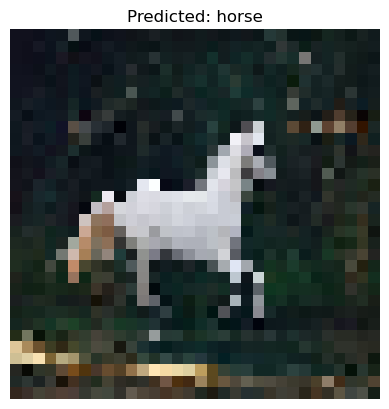

In [7]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import pandas as pd


# CIFAR-10 class names
class_names = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]

# Load and preprocess your image
img_path = "img1.jpg"   # 🔹 replace with your file path
img = image.load_img(img_path, target_size=(32, 32))   # resize to CIFAR-10 size
img_array = image.img_to_array(img) / 255.0            # normalize
img_array = np.expand_dims(img_array, axis=0)          # add batch dimension

# Predict
pred = model.predict(img_array)
pred_class = np.argmax(pred)
pred_prob = pred.flatten()  
# Create a table of probabilities
prob_table = pd.DataFrame({
    "Class": class_names,
    "Probability": pred_prob
}).sort_values(by="Probability", ascending=False)

print(prob_table)


# Show image and prediction
plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted: {class_names[pred_class]}")
plt.show()


### Handling Images Not Belonging to Known Classes

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
        Class  Probability
3         cat     0.326232
5         dog     0.289464
9       truck     0.097725
2        bird     0.083930
6        frog     0.078815
4        deer     0.064528
7       horse     0.036274
8        ship     0.010700
0    airplane     0.008290
1  automobile     0.004042


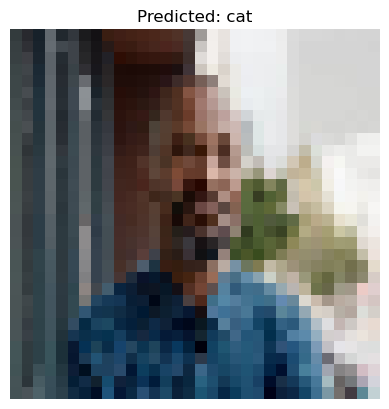

In [8]:
# Load and preprocess your image
img_path = "img2.jpg"   # 🔹 replace with your file path
img = image.load_img(img_path, target_size=(32, 32))   # resize to CIFAR-10 size
img_array = image.img_to_array(img) / 255.0            # normalize
img_array = np.expand_dims(img_array, axis=0)          # add batch dimension

# Predict
pred = model.predict(img_array)
pred_class = np.argmax(pred)
pred_prob = pred.flatten()  
# Create a table of probabilities
prob_table = pd.DataFrame({
    "Class": class_names,
    "Probability": pred_prob
}).sort_values(by="Probability", ascending=False)

print(prob_table)


# Show image and prediction
plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted: {class_names[pred_class]}")
plt.show()